# Visual proof of concept: grouping disaster-recovery curves

This teaching notebook uses **dummy data only**. Its purpose is to make every analytical step visible before the same logic is applied to reliability-qualified VIIRS Black Marble observations.

The demonstration follows 24 fictional municipalities from 60 days before to 360 days after a fictional event. Their trajectories were deliberately generated from four known recovery behaviours so that we can check whether the method finds the structure we put into the data.


### What the notebook demonstrates

1. Raw radiance and baseline normalisation.
2. Missing observations and common time bins.
3. The feature matrix used by clustering.
4. Pairwise distances and the choice of cluster count.
5. K-means assignment and a spatial family map.
6. Ordinary curves, pointwise summaries and a functional boxplot.
7. T50/T80/T90 grouping as a separate summary.
8. Sensitivity to low baseline brightness.
9. Stable, uninterrupted reference trajectories.
10. Alignment and divergence with physical EO and survey evidence.

All family labels and findings are illustrative. They are not empirical results for Samar-Leyte.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import rankdata
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, silhouette_score, adjusted_rand_score

In [15]:
RNG = np.random.default_rng(42)
EVENT_COLOR = "#0057FF"
TEXT_COLOR = "#243B5A"
GRID_COLOR = "#E8EDF3"
BASELINE_COLOR = "#6C7882"
FAMILY_COLORS = {
    "Rapid return": "#0072B2",
    "Gradual return": "#E69F00",
    "Persistent suppression": "#D55E00",
    "Overshoot": "#009E73",
}
CLUSTER_COLORS = ["#0072B2", "#E69F00", "#D55E00", "#009E73", "#CC79A7", "#56B4E9"]

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 14, "axes.labelsize": 12,
    "axes.edgecolor": "#BCC6D1", "axes.labelcolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR, "ytick.color": TEXT_COLOR,
    "text.color": TEXT_COLOR, "axes.titlecolor": TEXT_COLOR,
    "axes.grid": True, "grid.color": GRID_COLOR, "grid.linewidth": 0.8,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def event_line(ax):
    ax.axvline(0, color=EVENT_COLOR, linestyle="--", linewidth=1.6)
    ax.text(2, 0.98, "Event", color=EVENT_COLOR, transform=ax.get_xaxis_transform(),
            va="top", fontsize=10)

def finish(fig, title=None):
    if title:
        fig.suptitle(title, x=0.02, ha="left", fontsize=18, fontweight="bold", color=TEXT_COLOR)
    fig.tight_layout(rect=(0, 0, 1, 0.94 if title else 1))
    plt.show()

## 1. Generate transparent dummy observations

Each municipality has a baseline radiance, one known recovery family, and four-day observations. Noise increases as baseline brightness decreases. Some observations are removed to imitate cloud-related gaps.

The four planted behaviours are:

- **Rapid return:** sharp impact followed by a quick approach to baseline.
- **Gradual return:** sharp impact followed by a slower recovery.
- **Persistent suppression:** severe impact with recovery remaining below baseline.
- **Overshoot:** recovery followed by a temporary above-baseline peak.

The “true” families are shown only for teaching. In a real study they are unknown.

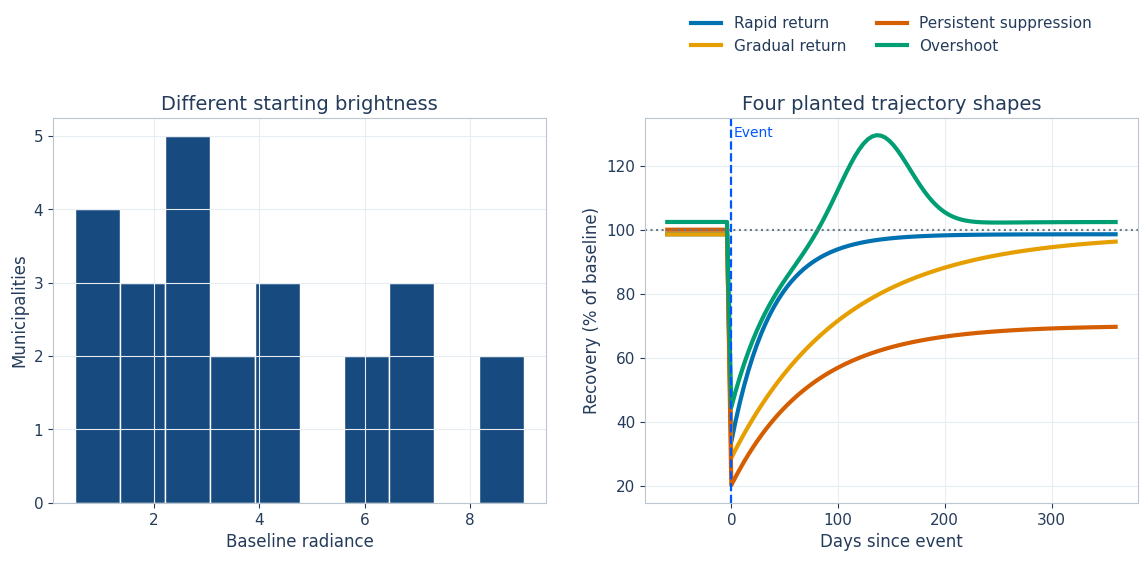

In [16]:
names = [f"Municipality {i:02d}" for i in range(1, 25)]
days = np.arange(-60, 361, 4)
family_names = list(FAMILY_COLORS)
true_family = {name: family_names[(i // 6)] for i, name in enumerate(names)}
baseline = pd.Series(np.exp(RNG.normal(np.log(3.0), 0.9, len(names))), index=names, name="baseline_radiance")

def planted_curve(day, family):
    if day < 0:
        return 100.0
    if family == "Rapid return":
        return 100 - 65*np.exp(-day/38)
    if family == "Gradual return":
        return 100 - 70*np.exp(-day/105)
    if family == "Persistent suppression":
        return 70 - 50*np.exp(-day/75)
    return 100 - 58*np.exp(-day/45) + 30*np.exp(-((day-135)/45)**2)

rows = []
for i, name in enumerate(names):
    b = baseline[name]
    level_shift = RNG.normal(0, 3)
    for day in days:
        truth = planted_curve(day, true_family[name]) + level_shift
        # Low-radiance places receive larger percentage variation from the same radiance disturbance.
        pct_noise_sd = 4 + 10/np.sqrt(b)
        observed_pct = truth + RNG.normal(0, pct_noise_sd)
        raw_radiance = max(0, b * observed_pct / 100)
        missing_probability = 0.10 + 0.12*(np.sin((day+30)/55)**2)
        observed = RNG.random() > missing_probability
        rows.append((name, day, true_family[name], b, truth,
                     raw_radiance if observed else np.nan,
                     observed_pct if observed else np.nan))

data = pd.DataFrame(rows, columns=[
    "municipality", "day", "true_family", "baseline_radiance",
    "latent_recovery", "raw_radiance", "recovery_pct",
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(baseline, bins=10, color="#174A7E", edgecolor="white")
axes[0].set(xlabel="Baseline radiance", ylabel="Municipalities",
            title="Different starting brightness")
for family in family_names:
    g = data[(data.true_family == family) & (data.municipality == data.loc[data.true_family == family, "municipality"].iloc[0])]
    axes[1].plot(g.day, g.latent_recovery, color=FAMILY_COLORS[family], linewidth=3, label=family)
event_line(axes[1]); axes[1].axhline(100, color=BASELINE_COLOR, linestyle=":")
axes[1].set(xlabel="Days since event", ylabel="Recovery (% of baseline)",
            title="Four planted trajectory shapes")

axes[1].legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.30))
# finish(fig, "Step 1 · What exists in the synthetic world")

## 2. Raw radiance versus normalised recovery

Raw radiance answers “how bright was the municipality?” Normalised recovery answers “how bright was it relative to its own pre-event level?” A municipality with baseline radiance 1 and current radiance 0.8 is at 80%; one with baseline 10 and current radiance 8 is also at 80%.

Normalisation makes trajectories comparable, but it can amplify small absolute fluctuations when the denominator is dim. The right panel therefore does not remove the need to inspect baseline brightness.

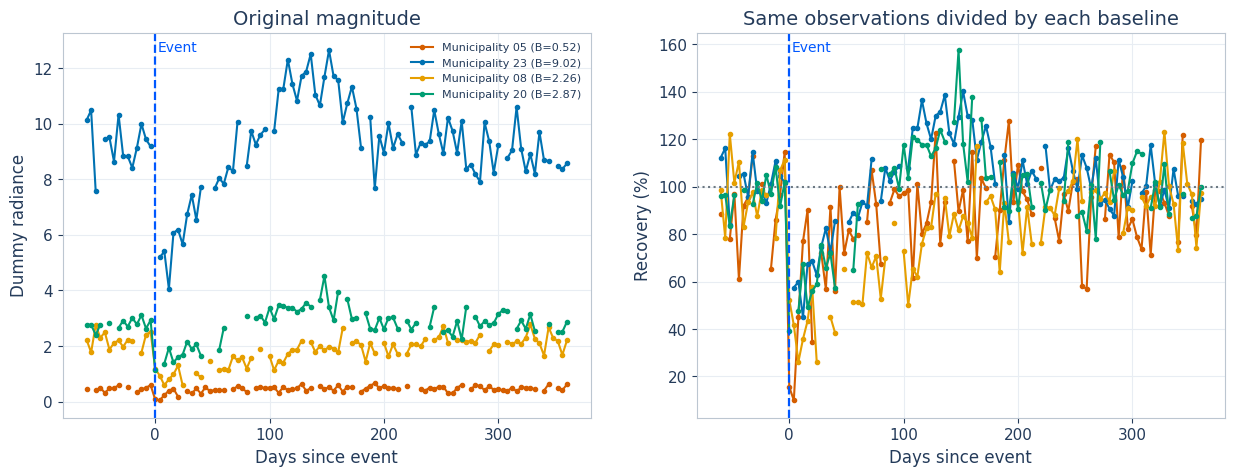

In [17]:
examples = [names[baseline.argmin()], names[baseline.argmax()], "Municipality 08", "Municipality 20"]
example_colors = ["#D55E00", "#0072B2", "#E69F00", "#009E73"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

for name, color in zip(examples, example_colors):
    g = data[data.municipality == name]
    label = f"{name} (B={baseline[name]:.2f})"
    axes[0].plot(g.day, g.raw_radiance, "o-", ms=3, lw=1.5, color=color, label=label)
    axes[1].plot(g.day, g.recovery_pct, "o-", ms=3, lw=1.5, color=color, label=label)
for ax in axes: event_line(ax)
axes[1].axhline(100, color=BASELINE_COLOR, linestyle=":", label="Baseline")
axes[0].set(title="Original magnitude", xlabel="Days since event", ylabel="Dummy radiance")
axes[1].set(title="Same observations divided by each baseline", xlabel="Days since event", ylabel="Recovery (%)")
axes[0].legend(frameon=False, fontsize=8, ncol=1, loc="upper right")
# finish(fig, "Step 2 · Normalisation changes the comparison")


## 3. See the observations and the gaps before grouping

The upper panel shows every normalised trajectory. The lower panel shows whether each four-day observation exists. Blank periods are unavailable observations, not zero recovery.

Clustering requires comparable inputs. We therefore summarise the first 180 post-event days into nine fixed 20-day bins. Each bin contains up to five four-day observations. A bin is retained only when at least two observations exist.

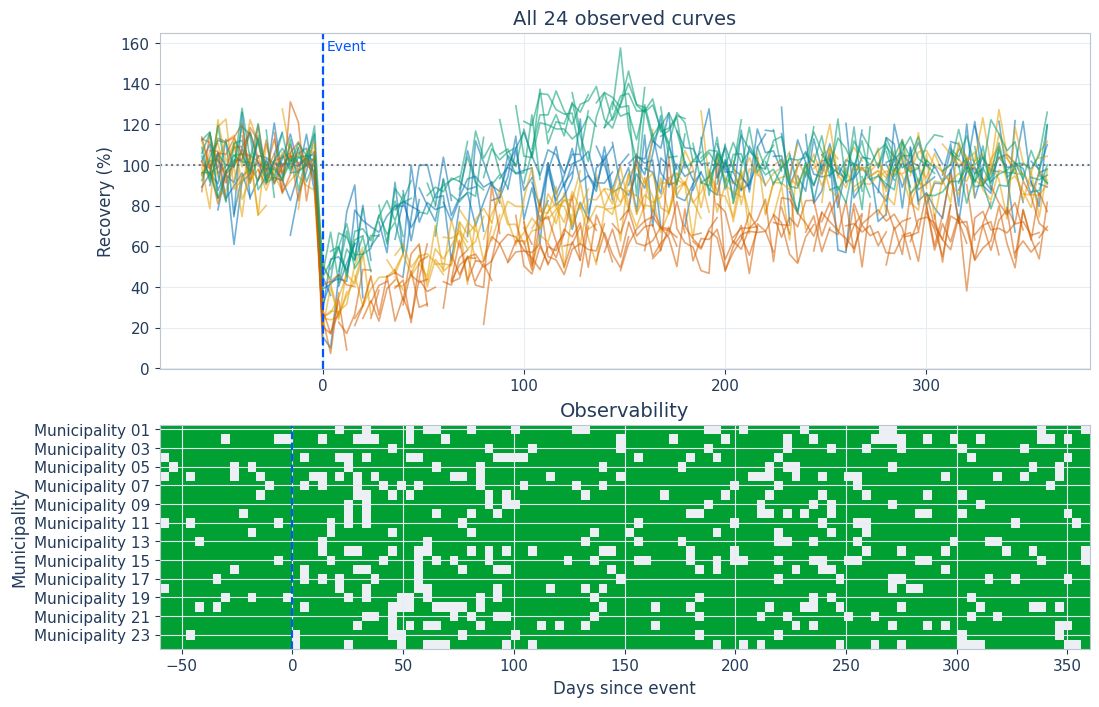

In [18]:
observed_matrix = data.pivot(index="municipality", columns="day", values="recovery_pct").reindex(names)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [0.6, 0.4]})
for name in names:
    g = data[data.municipality == name]
    axes[0].plot(g.day, g.recovery_pct, color=FAMILY_COLORS[true_family[name]], alpha=0.55, lw=1.2)
event_line(axes[0]); axes[0].axhline(100, color=BASELINE_COLOR, linestyle=":")
axes[0].set(ylabel="Recovery (%)", title="All 24 observed curves")
im = axes[1].imshow(observed_matrix.notna(), aspect="auto", interpolation="nearest",
                    cmap=ListedColormap(["#ECEFF3", "#00A033"]),
                    extent=[days.min(), days.max(), len(names)-0.5, -0.5])
axes[1].axvline(0, color=EVENT_COLOR, linestyle="--", linewidth=1.5)
axes[1].set(xlabel="Days since event", ylabel="Municipality", title="Observability")
axes[1].set_yticks(np.arange(len(names))[::2], names[::2])
# finish(fig, "Step 3 · The curves are not equally observed")

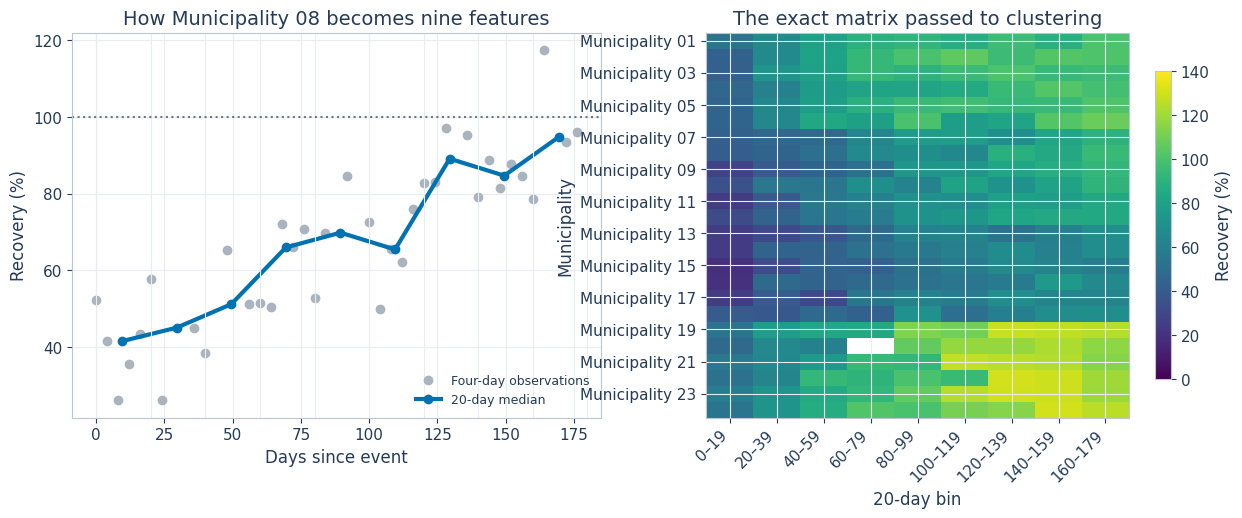

In [19]:
post = data[data.day.between(0, 179)].copy()
post["bin"] = (post.day // 20).astype(int)
grouped = post.groupby(["municipality", "bin"])["recovery_pct"]
feature_matrix = grouped.median().unstack("bin").reindex(index=names, columns=range(9))
count_matrix = grouped.count().unstack("bin").reindex(index=names, columns=range(9)).fillna(0)
feature_matrix = feature_matrix.where(count_matrix >= 2)
bin_mid = np.arange(9)*20 + 9.5

focus = names[7]
g = post[post.municipality == focus]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(g.day, g.recovery_pct, "o", color="#AAB4BE", label="Four-day observations")
axes[0].plot(bin_mid, feature_matrix.loc[focus], "o-", color="#0072B2", lw=3, label="20-day median")
for x in np.arange(0, 181, 20): axes[0].axvline(x, color=GRID_COLOR, lw=0.8)
axes[0].axhline(100, color=BASELINE_COLOR, linestyle=":")
axes[0].set(xlabel="Days since event", ylabel="Recovery (%)", title=f"How {focus} becomes nine features")
axes[0].legend(frameon=False, loc="lower right", fontsize=9)
masked = np.ma.masked_invalid(feature_matrix.values)
im = axes[1].imshow(masked, aspect="auto", cmap="viridis", vmin=0, vmax=140)
axes[1].set(title="The exact matrix passed to clustering", xlabel="20-day bin", ylabel="Municipality")
axes[1].set_xticks(range(9), [f"{i*20}–{i*20+19}" for i in range(9)], rotation=45, ha="right")
axes[1].set_yticks(range(0, 24, 2), names[::2])
fig.colorbar(im, ax=axes[1], label="Recovery (%)", shrink=0.8)
# finish(fig, "Step 4 · Curves become a common feature matrix")

## 4. Measure similarity before asking for clusters

For each pair of municipalities, calculate the root-mean-square difference across their nine shared bins. A small value means their recovery levels and timing are similar on the common calendar. No spatial coordinates or municipality names enter the distance calculation.

K-means then searches for centres that minimise the squared distances between each curve and its assigned centre. The silhouette score compares within-cluster closeness with separation from other clusters; larger values indicate clearer separation. It informs the choice of *k* but does not decide it scientifically.

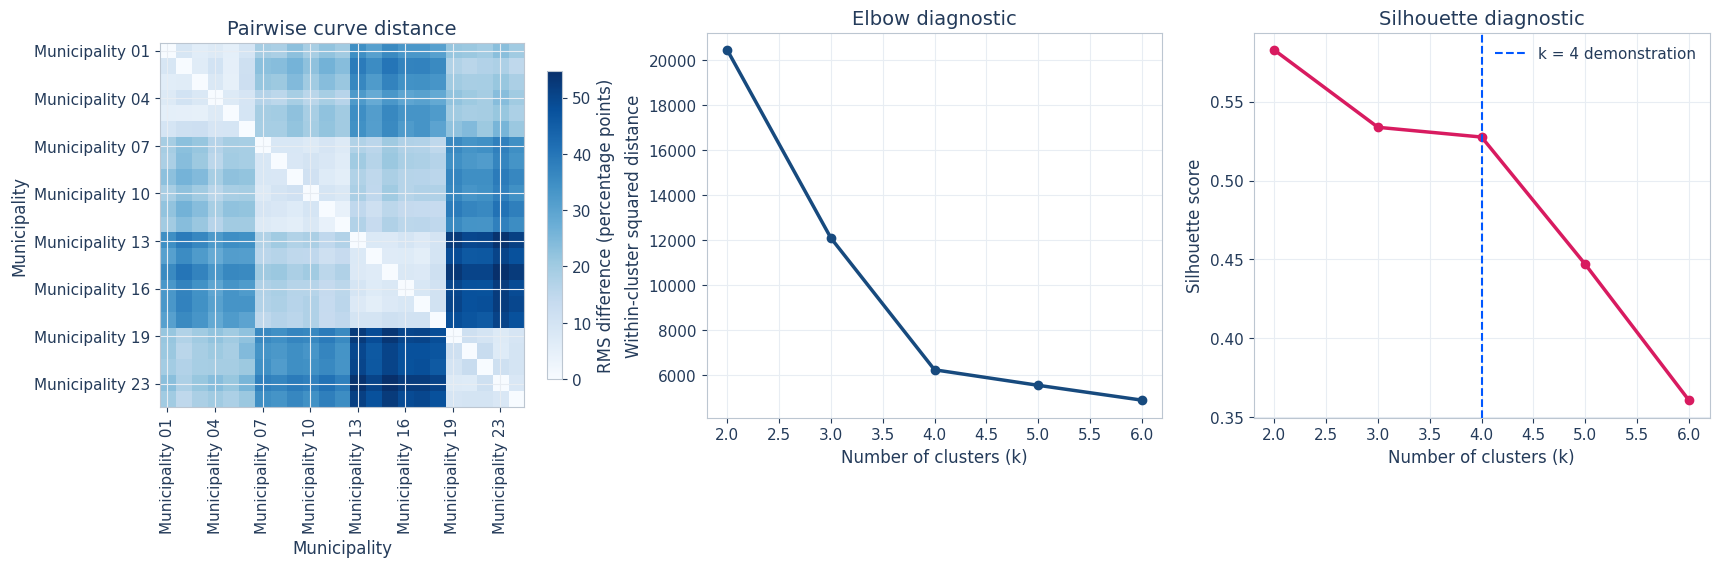

In [20]:
eligible = feature_matrix.dropna()
X = eligible.to_numpy()
distance = pairwise_distances(X) / np.sqrt(X.shape[1])
ks = range(2, 7)
inertia, silhouettes = [], []
for k in ks:
    model = KMeans(n_clusters=k, n_init=50, random_state=42).fit(X)
    inertia.append(model.inertia_)
    silhouettes.append(silhouette_score(X, model.labels_))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
im = axes[0].imshow(distance, cmap="Blues")
axes[0].set(title="Pairwise curve distance", xlabel="Municipality", ylabel="Municipality")
axes[0].set_xticks(range(0, len(eligible), 3), eligible.index[::3], rotation=90)
axes[0].set_yticks(range(0, len(eligible), 3), eligible.index[::3])
fig.colorbar(im, ax=axes[0], label="RMS difference (percentage points)", shrink=.8)
axes[1].plot(list(ks), inertia, "o-", color="#174A7E", lw=2.5)
axes[1].set(title="Elbow diagnostic", xlabel="Number of clusters (k)", ylabel="Within-cluster squared distance")
axes[2].plot(list(ks), silhouettes, "o-", color="#D81B60", lw=2.5)
axes[2].set(title="Silhouette diagnostic", xlabel="Number of clusters (k)", ylabel="Silhouette score")
axes[2].axvline(4, color=EVENT_COLOR, linestyle="--", label="k = 4 demonstration")
axes[2].legend(frameon=False)
# finish(fig, "Step 5 · Similarity and the cluster-count decision")

## 5. Fit four exploratory families and map them

This demonstration sets *k = 4* because four behaviours were planted. In real data, the analyst would compare diagnostics, stability under resampling, interpretability, minimum family size, and sensitivity to preprocessing.

Cluster numbers are arbitrary. They are renamed by the order of their final recovery level so that labels remain reproducible. Thick dashed lines are cluster centres; thin lines are member municipalities.

Teaching check: adjusted Rand index against planted families = 1.000
This check is possible only because the dummy-data truth is known.


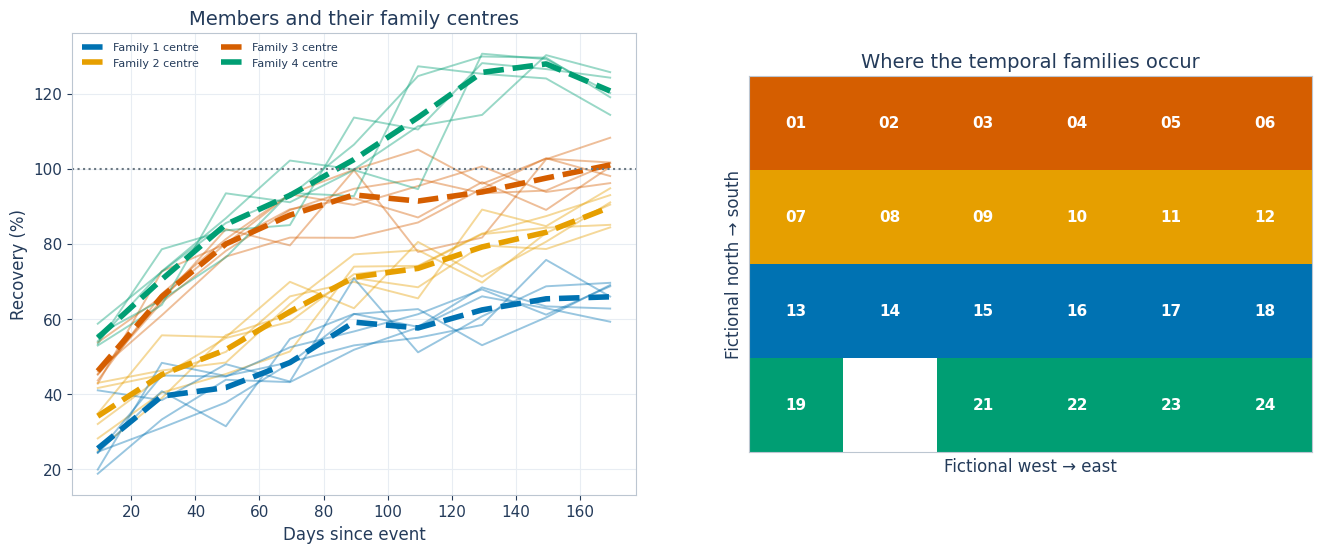

In [21]:
k = 4
model = KMeans(n_clusters=k, n_init=100, random_state=42).fit(X)
order = np.argsort(model.cluster_centers_[:, -1])
label_map = {old: new for new, old in enumerate(order)}
cluster_id = pd.Series([label_map[x] for x in model.labels_], index=eligible.index, name="cluster")
centres = np.vstack([model.cluster_centers_[old] for old in order])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, values in eligible.iterrows():
    c = cluster_id[name]
    axes[0].plot(bin_mid, values, color=CLUSTER_COLORS[c], alpha=.40, lw=1.4)
for c in range(k):
    axes[0].plot(bin_mid, centres[c], color=CLUSTER_COLORS[c], lw=4, linestyle="--", label=f"Family {c+1} centre")
axes[0].axhline(100, color=BASELINE_COLOR, linestyle=":")
axes[0].set(xlabel="Days since event", ylabel="Recovery (%)", title="Members and their family centres")
axes[0].legend(frameon=False, ncol=2, loc="upper left", fontsize=8)

map_grid = np.full((4, 6), np.nan)
for i, name in enumerate(names): map_grid[i//6, i%6] = cluster_id.get(name, np.nan)
axes[1].imshow(map_grid, cmap=ListedColormap(CLUSTER_COLORS[:4]), vmin=-.5, vmax=3.5)
for i, name in enumerate(names):
    axes[1].text(i%6, i//6, name.split()[-1], ha="center", va="center", color="white", fontweight="bold")
axes[1].set(title="Where the temporal families occur", xlabel="Fictional west → east", ylabel="Fictional north → south")
axes[1].set_xticks([]); axes[1].set_yticks([])
# finish(fig, "Step 6 · Temporal grouping followed by spatial mapping")

truth_numeric = pd.Series([family_names.index(true_family[n]) for n in eligible.index], index=eligible.index)
print(f"Teaching check: adjusted Rand index against planted families = {adjusted_rand_score(truth_numeric, cluster_id):.3f}")
print("This check is possible only because the dummy-data truth is known.")

## 6. Functional boxplot versus the ordinary time-series display

The first panel keeps every identity. The second calculates quartiles independently at each time. The third ranks whole curves by modified band depth.

For each candidate curve, band depth asks: across the timeline, how often does this entire curve lie between pairs of other curves? The deepest observed curve becomes the functional median. The central envelope is formed by the deepest 50% of complete curves. It is not a confidence interval, and its edges are not pointwise quartiles.

The functional boxplot compresses the collection better; the ordinary plot preserves individual identities and gaps better. They answer different display needs.

Text(0, 0.5, 'Recovery (%)')

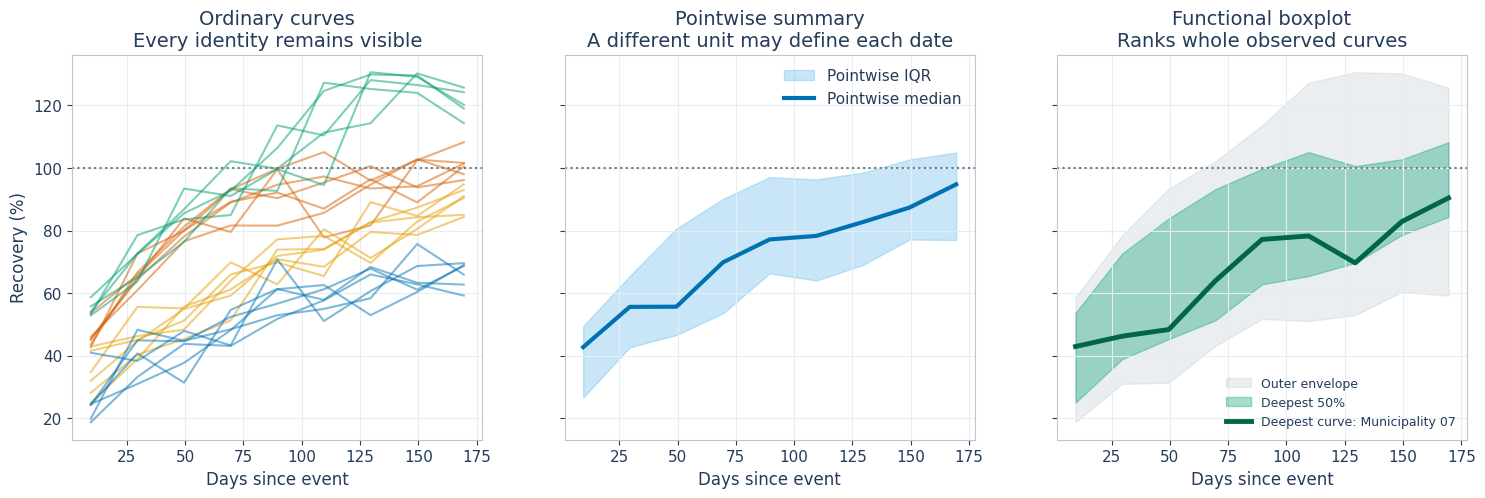

In [22]:
def functional_boxplot_summary(values):
    n = len(values)
    below = rankdata(values, method="min", axis=0) - 1
    above = n - rankdata(values, method="max", axis=0)
    depth = (1 - (below*(below-1) + above*(above-1))/(n*(n-1))).mean(axis=1)
    order = np.argsort(-depth, kind="stable")
    central = values[order[:int(np.ceil(n/2))]]
    low, high = central.min(axis=0), central.max(axis=0)
    fence_low, fence_high = low - 1.5*(high-low), high + 1.5*(high-low)
    flagged = ((values < fence_low) | (values > fence_high)).any(axis=1)
    outer = values[~flagged] if (~flagged).any() else values
    return dict(depth=depth, order=order, median=values[order[0]],
                low=low, high=high, outer_low=outer.min(0), outer_high=outer.max(0), flagged=flagged)

fb = functional_boxplot_summary(X)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, name in enumerate(eligible.index): axes[0].plot(bin_mid, X[i], color=CLUSTER_COLORS[cluster_id[name]], alpha=.5)
axes[0].set_title("Ordinary curves\nEvery identity remains visible")
q25, med, q75 = np.quantile(X, [.25, .5, .75], axis=0)
axes[1].fill_between(bin_mid, q25, q75, color="#56B4E9", alpha=.32, label="Pointwise IQR")
axes[1].plot(bin_mid, med, color="#0072B2", lw=3, label="Pointwise median")
axes[1].set_title("Pointwise summary\nA different unit may define each date")
axes[1].legend(frameon=False)
axes[2].fill_between(bin_mid, fb["outer_low"], fb["outer_high"], color="#BFC7CE", alpha=.3, label="Outer envelope")
axes[2].fill_between(bin_mid, fb["low"], fb["high"], color="#009E73", alpha=.35, label="Deepest 50%")
deepest_name = eligible.index[fb["order"][0]]
axes[2].plot(bin_mid, fb["median"], color="#006644", lw=3.5, label=f"Deepest curve: {deepest_name}")
for i in np.where(fb["flagged"])[0]: axes[2].plot(bin_mid, X[i], color="#D55E00", linestyle="--", lw=2)
axes[2].set_title("Functional boxplot\nRanks whole observed curves")
axes[2].legend(frameon=False, fontsize=9)
for ax in axes:
    ax.axhline(100, color=BASELINE_COLOR, linestyle=":")
    ax.set_xlabel("Days since event")
axes[0].set_ylabel("Recovery (%)")
# finish(fig, "Step 7 · Same data, three different summaries")

## 7. T50, T80 and T90 describe milestone timing, not the whole shape

For each municipality, find the first time it reaches each threshold for two consecutive observed four-day composites after its post-event minimum. If the threshold was never lost, the return time is undefined. If observations are insufficient or the threshold is not regained, its status remains explicit.

Clustering the three milestone times groups recovery timing. It can disagree with full-curve clustering because it discards fluctuations, overshoot and sustained differences between thresholds.

                 curve_family  timing_family
Municipality 01           2.0            3.0
Municipality 02           2.0            0.0
Municipality 03           2.0            0.0
Municipality 04           2.0            3.0
Municipality 05           2.0            0.0
Municipality 06           2.0            0.0
Municipality 07           1.0            2.0
Municipality 08           1.0            2.0
Municipality 09           1.0            1.0
Municipality 10           1.0            2.0
Municipality 11           1.0            1.0
Municipality 12           1.0            1.0
Municipality 13           0.0            NaN
Municipality 14           0.0            NaN
Municipality 15           0.0            NaN
Municipality 16           0.0            NaN
Municipality 17           0.0            NaN
Municipality 18           0.0            NaN
Municipality 19           3.0            3.0
Municipality 20           NaN            3.0
Municipality 21           3.0            0.0
Municipali

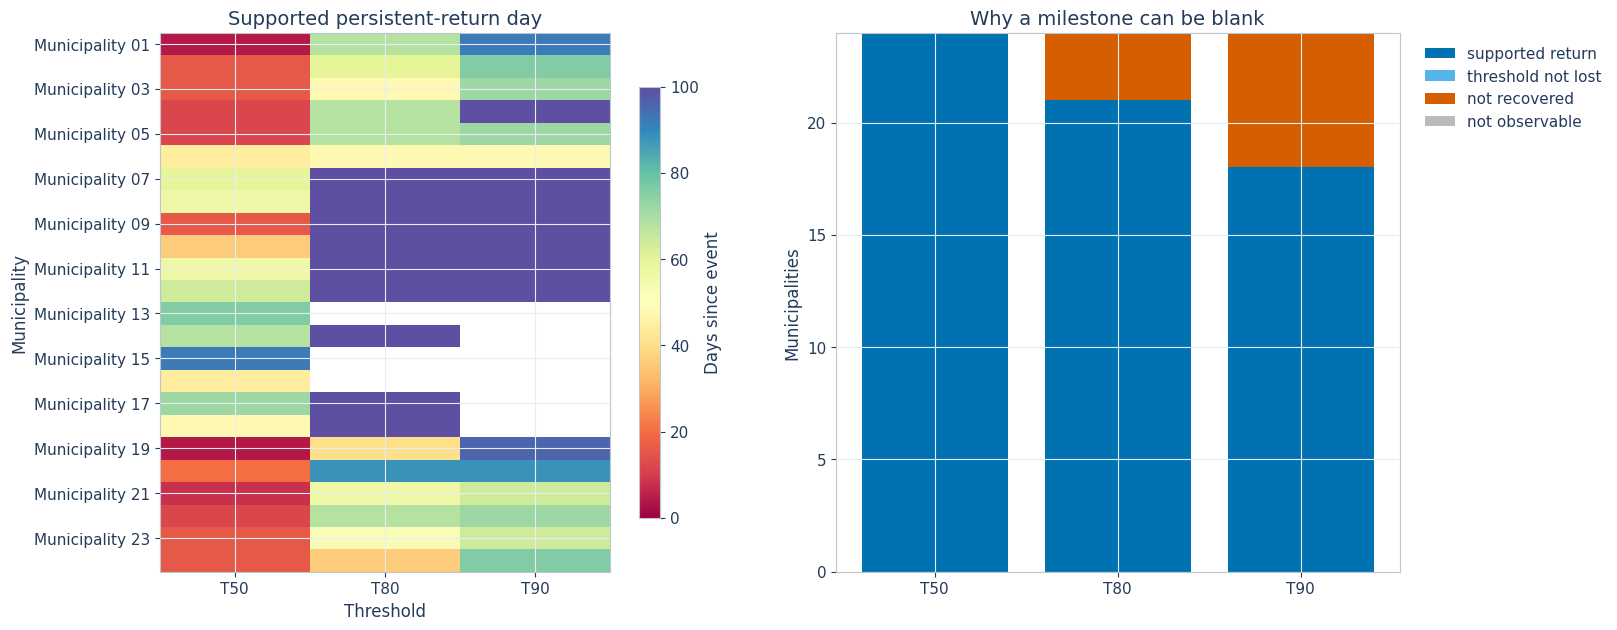

In [23]:
def persistent_time(group, threshold):
    g = group[(group.day >= 0) & group.recovery_pct.notna()].sort_values("day")
    if g.empty: return np.nan, "not observable"
    nadir_i = g.recovery_pct.idxmin()
    nadir = g.loc[nadir_i]
    if nadir.recovery_pct >= threshold: return np.nan, "threshold not lost"
    after = g[g.day >= nadir.day].set_index("day")
    for day in after.index:
        if day+4 in after.index and after.loc[day, "recovery_pct"] >= threshold and after.loc[day+4, "recovery_pct"] >= threshold:
            return day, "supported return"
    return np.nan, "not recovered"

records = []
for name in names:
    g = data[data.municipality == name]
    row = {"municipality": name}
    for t in (50, 80, 90):
        row[f"T{t}"], row[f"T{t}_status"] = persistent_time(g, t)
    records.append(row)
milestones = pd.DataFrame(records).set_index("municipality")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
im = axes[0].imshow(np.ma.masked_invalid(milestones[["T50","T80","T90"]]), aspect="auto", cmap="Spectral", vmin=0, vmax=100)
axes[0].set(title="Supported persistent-return day", xlabel="Threshold", ylabel="Municipality")
axes[0].set_xticks(range(3), ["T50","T80","T90"]); axes[0].set_yticks(range(0,24,2), names[::2])
fig.colorbar(im, ax=axes[0], label="Days since event", shrink=.8)
for j, t in enumerate((50,80,90)):
    status_counts = milestones[f"T{t}_status"].value_counts()
    bottom = 0
    for status, color in [("supported return","#0072B2"),("threshold not lost","#56B4E9"),("not recovered","#D55E00"),("not observable","#BBBBBB")]:
        value = status_counts.get(status, 0)
        axes[1].bar(f"T{t}", value, bottom=bottom, color=color, label=status if j==0 else None)
        bottom += value
axes[1].set(title="Why a milestone can be blank", ylabel="Municipalities")
axes[1].legend(frameon=False, bbox_to_anchor=(1.02,1), loc="upper left")
# finish(fig, "Step 8 · Preserve milestone status before grouping")

timing_eligible = milestones[["T50","T80","T90"]].dropna()
timing_groups = pd.Series(np.nan, index=names, name="timing_group")
if len(timing_eligible) >= 4:
    km_t = KMeans(n_clusters=min(4, len(timing_eligible)), n_init=50, random_state=42).fit(timing_eligible)
    timing_groups.loc[timing_eligible.index] = km_t.labels_
comparison = pd.DataFrame({"curve_family": cluster_id, "timing_family": timing_groups}).reindex(names)
print(comparison.to_string())
print("\nBlank timing families were not forced to day 0 or day 360.")

## 8. Check whether dim baselines drive the families

The synthetic generator deliberately makes dim municipalities noisier in percentage terms. First inspect the relationship between baseline brightness and pre-event variability. Then repeat clustering after reducing the low-baseline noise, standing in for a stricter brightness-support rule.

The adjusted Rand index compares original and sensitivity assignments: 1 means identical membership, 0 means no more agreement than chance. A membership change flags sensitivity; it does not prove that the original curve was wrong because changing support also changes what part of the municipality is represented.

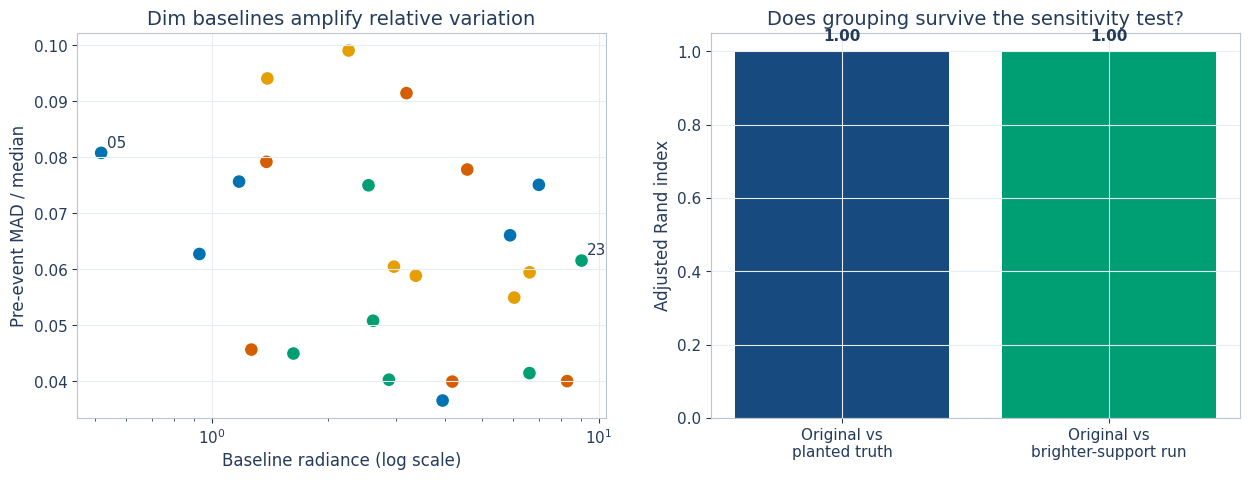

In [24]:
pre = data[data.day < 0].groupby("municipality").recovery_pct.agg(
    pre_median="median", pre_mad=lambda s: np.nanmedian(abs(s-np.nanmedian(s))))
diag = baseline.to_frame().join(pre)
diag["relative_variability"] = diag.pre_mad / diag.pre_median

# For teaching, shrink deviations around the planted signal most strongly for dim units.
sensitivity = data.copy()
weight = np.clip(np.sqrt(sensitivity.baseline_radiance / baseline.median()), .35, 1)
sensitivity["recovery_pct"] = sensitivity.latent_recovery + weight*(sensitivity.recovery_pct-sensitivity.latent_recovery)
s_post = sensitivity[sensitivity.day.between(0,179)].copy(); s_post["bin"]=(s_post.day//20).astype(int)
s_features = s_post.groupby(["municipality","bin"]).recovery_pct.median().unstack().reindex(index=names,columns=range(9))
s_counts = s_post.groupby(["municipality","bin"]).recovery_pct.count().unstack().reindex(index=names,columns=range(9)).fillna(0)
s_features = s_features.where(s_counts>=2).dropna()
common = eligible.index.intersection(s_features.index)
s_model = KMeans(n_clusters=4,n_init=100,random_state=42).fit(s_features.loc[common])
s_labels = pd.Series(s_model.labels_,index=common)
ari_sensitivity = adjusted_rand_score(cluster_id.loc[common], s_labels)

fig, axes = plt.subplots(1, 2, figsize=(15,5))
axes[0].scatter(diag.baseline_radiance, diag.relative_variability, c=[FAMILY_COLORS[true_family[n]] for n in diag.index], s=65)
axes[0].set_xscale("log"); axes[0].set(xlabel="Baseline radiance (log scale)", ylabel="Pre-event MAD / median", title="Dim baselines amplify relative variation")
for name in examples[:2]: axes[0].annotate(name.split()[-1], (diag.loc[name,"baseline_radiance"],diag.loc[name,"relative_variability"]), xytext=(4,4), textcoords="offset points")
axes[1].bar(["Original vs\nplanted truth","Original vs\nbrighter-support run"],
            [adjusted_rand_score(truth_numeric,cluster_id),ari_sensitivity], color=["#174A7E","#009E73"])
axes[1].set_ylim(0,1.05); axes[1].set(ylabel="Adjusted Rand index", title="Does grouping survive the sensitivity test?")
for i,v in enumerate([adjusted_rand_score(truth_numeric,cluster_id),ari_sensitivity]): axes[1].text(i,v+.03,f"{v:.2f}",ha="center",fontweight="bold")
# finish(fig, "Step 9 · Diagnose denominator sensitivity before interpretation")

## 9. Stable references show how an uninterrupted trajectory behaves

Six fictional reference areas are generated with no event impact. Their pre-event variation and post-event deviations define an empirical “quiet” range. A disaster trajectory extending beyond that range is easier to distinguish from ordinary fluctuation.

In real work, stability alone does not make a valid counterfactual. Candidate controls also need comparable seasonality, settlement form, baseline brightness, viewing conditions and exposure, plus independent evidence that they were not disrupted.

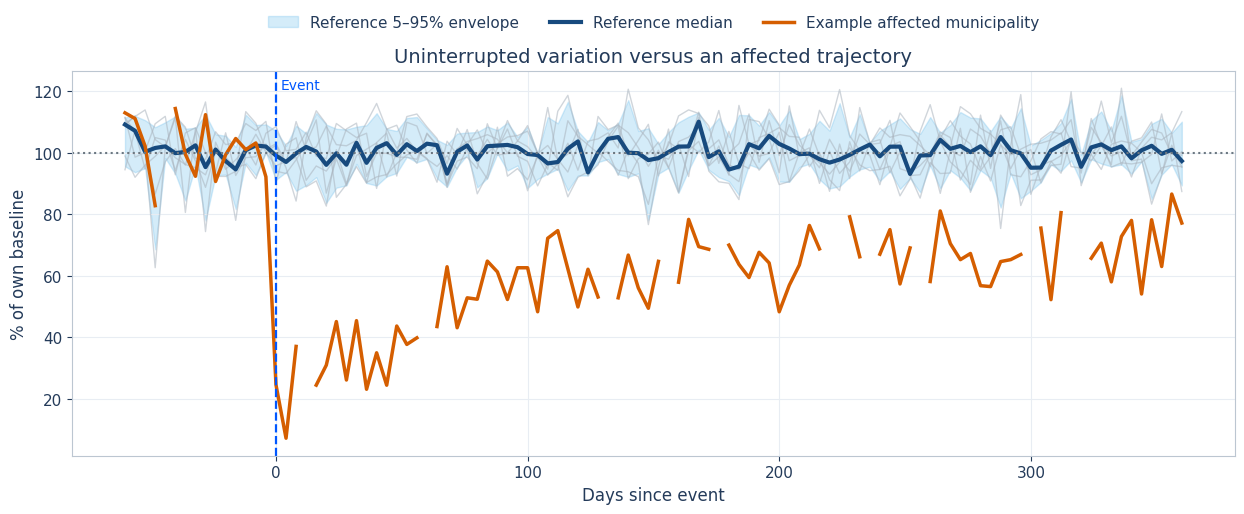

In [25]:
ref_names=[f"Reference {i}" for i in range(1,7)]
ref_rows=[]
for i,name in enumerate(ref_names):
    b=np.exp(RNG.normal(np.log(4),.5))
    seasonal=4*np.sin(2*np.pi*(days+20)/180+i)
    vals=100+seasonal+RNG.normal(0,4+5/np.sqrt(b),len(days))
    for d,v in zip(days,vals): ref_rows.append((name,d,b,v))
refs=pd.DataFrame(ref_rows,columns=["reference","day","baseline_radiance","recovery_pct"])
ref_wide=refs.pivot(index="reference",columns="day",values="recovery_pct")
quiet_low=ref_wide.quantile(.05); quiet_high=ref_wide.quantile(.95); quiet_med=ref_wide.median()

fig,ax=plt.subplots(figsize=(15,5))
for name,g in refs.groupby("reference"): ax.plot(g.day,g.recovery_pct,color="#AAB4BE",alpha=.55,lw=1)
ax.fill_between(days,quiet_low,quiet_high,color="#56B4E9",alpha=.25,label="Reference 5–95% envelope")
ax.plot(days,quiet_med,color="#174A7E",lw=3,label="Reference median")
affected=data[data.municipality=="Municipality 13"]
ax.plot(affected.day,affected.recovery_pct,color="#D55E00",lw=2.5,label="Example affected municipality")
event_line(ax); ax.axhline(100,color=BASELINE_COLOR,linestyle=":")
ax.set(xlabel="Days since event",ylabel="% of own baseline",title="Uninterrupted variation versus an affected trajectory")
ax.legend(frameon=False,ncol=3,loc="upper center",bbox_to_anchor=(.5,1.18))
# finish(fig,"Step 10 · Stable references provide a behavioural contrast")

## 10. Recovery families become useful when linked to other evidence

The final dummy example adds one physical EO indicator and one household indicator:

- **Physical EO:** reconstructed building share.
- **Ground survey:** household functional recovery score.

Both are simulated from the planted recovery process with deliberate disagreements. These disagreements are analytically useful. NTL can recover before buildings when temporary activity or alternative facilities restore lighting. Buildings can recover before NTL when structures exist but electricity, occupancy or nighttime activity remain limited.

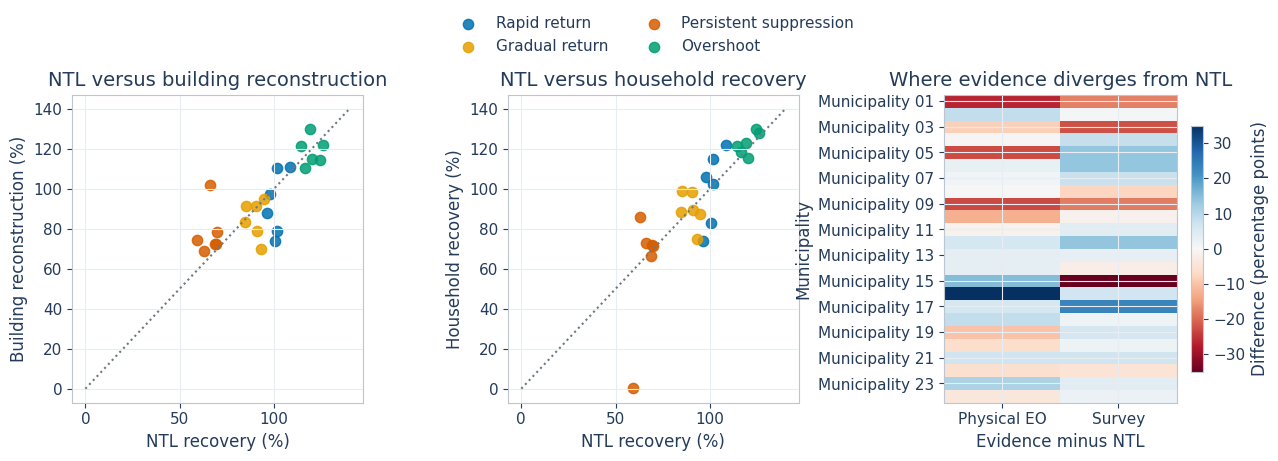

In [26]:
evidence=[]
for name in names:
    fam=true_family[name]
    ntl_end=float(feature_matrix.loc[name].iloc[-1])
    physical=np.clip(ntl_end+RNG.normal(0,10)+(12 if fam=="Persistent suppression" else -5),0,130)
    household=np.clip(ntl_end+RNG.normal(0,12)+(-18 if name in names[::7] else 0),0,130)
    evidence.append((name,ntl_end,physical,household,fam))
evidence=pd.DataFrame(evidence,columns=["municipality","NTL","Physical EO","Household survey","true_family"]).set_index("municipality")

fig,axes=plt.subplots(1,3,figsize=(15,4), gridspec_kw={"width_ratios": [0.3, 0.3, 0.3], "wspace": 0.5})
for ax,y,label in [(axes[0],"Physical EO","Building reconstruction"),(axes[1],"Household survey","Household recovery")]:
    for fam in family_names:
        g=evidence[evidence.true_family==fam]
        ax.scatter(g.NTL,g[y],s=55,color=FAMILY_COLORS[fam],label=fam,alpha=.85)
    ax.plot([0,140],[0,140],color=BASELINE_COLOR,linestyle=":")
    ax.set(xlabel="NTL recovery (%)",ylabel=f"{label} (%)",title=f"NTL versus {label.lower()}")
diff=np.column_stack([evidence["Physical EO"]-evidence.NTL,evidence["Household survey"]-evidence.NTL])
im=axes[2].imshow(diff,aspect="auto",cmap="RdBu",vmin=-35,vmax=35)
axes[2].set(title="Where evidence diverges from NTL",xlabel="Evidence minus NTL",ylabel="Municipality")
axes[2].set_xticks([0,1],["Physical EO","Survey"]); axes[2].set_yticks(range(0,24,2),names[::2])
fig.colorbar(im,ax=axes[2],label="Difference (percentage points)",shrink=.8)
axes[0].legend(frameon=False,ncol=2,loc="upper center",bbox_to_anchor=(2,1.3))
# finish(fig,"Step 11 · Use other evidence to explain convergence and divergence")

## How to interpret the demonstration

The workflow does not ask one method to do everything:

| Tool | Main role | Information lost |
|---|---|---|
| Individual time series | Inspect observations, gaps and local detail | Hard to compare many curves |
| Functional boxplot | Show the central whole curve, central envelope and unusual curves | Municipality identities are compressed |
| Curve clustering | Group similar recovery levels and shapes | Requires a distance, common support and chosen *k* |
| T50/T80/T90 | Communicate persistent threshold timing | Discards most of the path between milestones |
| Spatial family map | Reveal geographic organisation | Does not explain the process |
| Physical EO and surveys | Test mechanisms and interpret divergence | Different temporal and spatial support |

### Papers linked to the methods

- [Sun and Genton (2011), Functional Boxplots](https://doi.org/10.1198/jcgs.2011.09224) introduced centre-outward ranking, a functional median and central envelopes for collections of curves. It is a general statistical method; this notebook demonstrates its possible use for recovery profiles.
- [Zheng et al. (2025), Nighttime lights reveal substantial spatial heterogeneity and inequality in post-hurricane recovery](https://doi.org/10.1016/j.rse.2025.114645) used daily Black Marble time series, Bayesian change detection and temporal clustering at built-up pixel scale across ten hurricanes. This is the closest direct precedent for NTL recovery-trajectory clustering.
- [Hsu and Mostafavi (2025), Dissecting resilience curve archetypes and properties in human systems facing weather hazards](https://doi.org/10.1038/s41598-025-95909-8) examined resilience-curve archetypes more generally and supports separating curve shape from summary properties.
- [Barton-Henry and Wenz (2022), Nighttime light data reveal lack of full recovery after hurricanes in Southern US](https://doi.org/10.1088/1748-9326/ac998d) constructed longer-term NTL recovery timelines and related differences to aid and socioeconomic factors using quasi-experimental and machine-learning methods.

### Before moving to the real Notebook 4

Replace the dummy matrix with reliability-qualified pixel or municipality profiles only after checking baseline brightness, retained observations, common temporal support and sensitivity to preprocessing. For the six municipalities in Notebook 3, treat clustering as a visual proof of concept. A systematic typology needs a larger eligible population, cluster-stability tests, spatial diagnostics and independent physical or household evidence.